In [1]:
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core import Lattice
import matplotlib.pyplot as plt
import numpy as np

# Mg4Zn7 MEAM-relaxed lattice from cell vectors
a_vec = [26.3536, 0, 0]
b_vec = [0, 5.33657, 0]
c_vec = [-3.12791, 0, 14.1091]
lattice = Lattice([a_vec, b_vec, c_vec])

print(f"Lattice parameters:")
print(f"  a={lattice.a:.4f}, b={lattice.b:.4f}, c={lattice.c:.4f}")
print(f"  alpha={lattice.alpha:.2f}, beta={lattice.beta:.2f}, gamma={lattice.gamma:.2f}")

miller_indices = [
    (0, 0, 1),
    (0, 1, 0),
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
]

surface_energies = [
    0.5657,  # (001)
    1.3226,  # (010)
    0.6268,  # (100)
    0.6543,  # (101)
    0.6506,  # (110)
]

wulff = WulffShape(lattice, miller_indices, surface_energies)

print(f"\nWulff shape summary:")
print(f"  Weighted surface energy: {wulff.weighted_surface_energy:.4f} J/m²")
print(f"  Anisotropy: {wulff.anisotropy:.4f}")
print(f"  Shape factor: {wulff.shape_factor:.4f}")

print(f"\n  {'Plane':>8} {'γ (J/m²)':>10} {'Area frac':>10}")
print("  " + "-" * 32)
for facet, energy in zip(miller_indices, surface_energies):
    area_frac = wulff.area_fraction_dict.get(tuple(facet), 0)
    print(f"  {str(facet):>8} {energy:>10.4f} {area_frac:>10.4f}")

Lattice parameters:
  a=26.3536, b=5.3366, c=14.4517
  alpha=90.00, beta=102.50, gamma=90.00

Wulff shape summary:
  Weighted surface energy: 0.6173 J/m²
  Anisotropy: 0.0594
  Shape factor: 5.8256

     Plane   γ (J/m²)  Area frac
  --------------------------------
  (0, 0, 1)     0.5657     0.3195
  (0, 1, 0)     1.3226     0.0000
  (1, 0, 0)     0.6268     0.2704
  (1, 0, 1)     0.6543     0.0600
  (1, 1, 0)     0.6506     0.3502


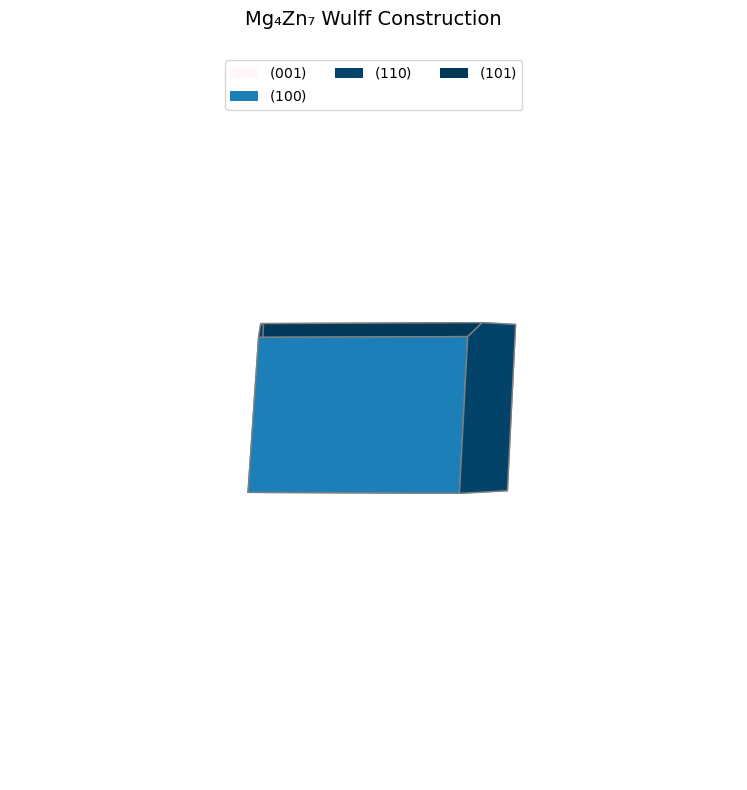

In [3]:
ax = wulff.get_plot()
fig = ax.get_figure()
fig.set_size_inches(8, 8)
plt.title("Mg₄Zn₇ Wulff Construction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

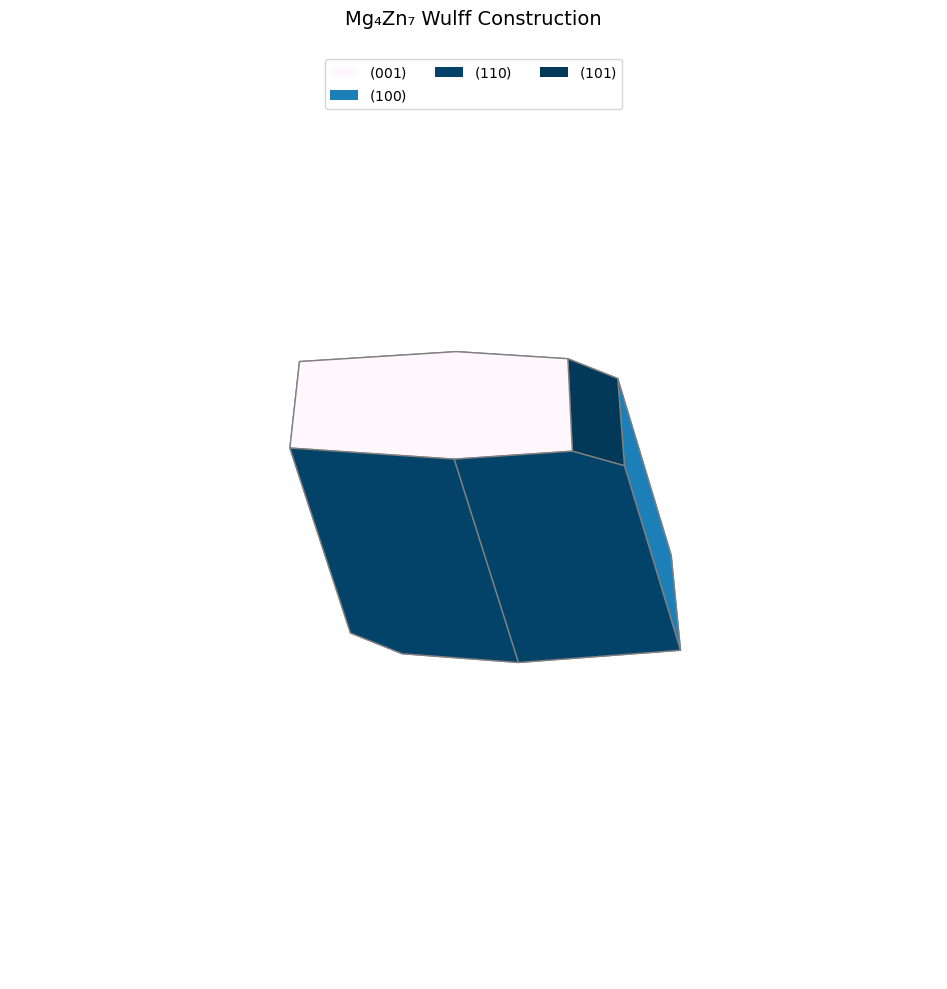

In [9]:
ax = wulff.get_plot()
fig = ax.get_figure()
fig.set_size_inches(10, 10)

# Try different viewing angles
ax.view_init(elev=20, azim=270)
plt.title("Mg₄Zn₇ Wulff Construction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()